# 04 — Lifetime PD: Discrete-Time Survival Analysis & IFRS 9

## Why This Notebook Exists

The PD model in Notebook 02 answers one question: *will this loan ever default?* That is a single yes/no probability over the loan's whole life. **IFRS 9** — the accounting standard that governs how lenders provision for credit losses — needs something richer: a **term structure** of default risk, i.e. the probability of default in *each future month*, so that two different loss allowances can be computed:

- **12-month Expected Credit Loss (ECL)** — losses expected from defaults in the next 12 months (Stage 1 loans).
- **Lifetime ECL** — losses expected over the entire remaining life (Stage 2 and Stage 3 loans).

To get a term structure we move from a static classifier to **discrete-time survival analysis** (a pooled logistic hazard model). This is the technique most recommended in recent IFRS 9 literature for dynamic lifetime PD.

| Concept | Meaning |
|---|---|
| Hazard `h(t)` | P(default in month t \| survived to month t) |
| Survival `S(t)` | P(no default through month t) = ∏(1 − h(s)) |
| Cumulative PD `F(t)` | 1 − S(t) |
| Marginal PD | S(t−1) × h(t) — probability of defaulting *exactly* in month t |
| 12-month PD | F(12) |
| Lifetime PD | F(term) |


In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as C
from src import data as D
from src import survival as S
from src import profit as P
from src.features import clean_frame
sns.set_style("whitegrid")

df = clean_frame(D.load_resolved(n=C.SURVIVAL_SAMPLE))
train_idx, test_idx = D.vintage_holdout_split(df)
print(f"Loans: {len(df):,}  |  train {len(train_idx):,}  test {len(test_idx):,}")

Loans: 50,000  |  train 37,500  test 12,500


## 1. Time-to-Event Construction

Each loan becomes a sequence of monthly observations (the **person-period** format). A charged-off loan contributes a `0` for every month it survived and a `1` in the month it defaulted (approximated by the last payment month). A fully-paid loan is **censored** — it contributes `0`s up to payoff and then leaves the risk set without an event. The monthly hazard is then just a logistic regression on these person-period rows, with loan age `t` entered flexibly (period, period², log period) as the baseline hazard.

Person-period rows: 899,968
Monthly event (hazard) rate: 0.8003%


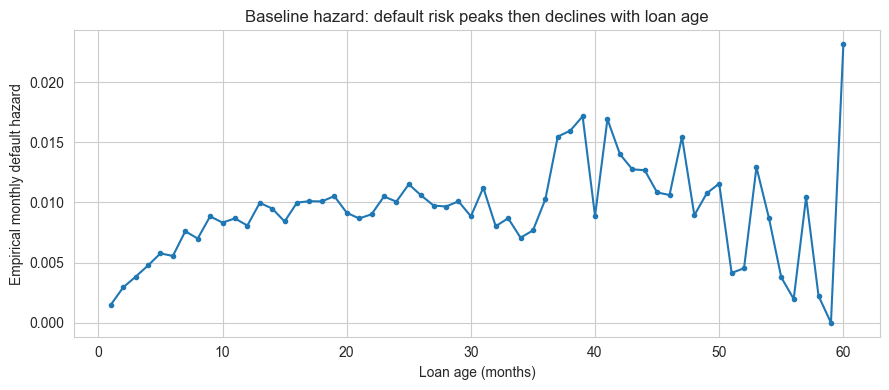

In [2]:
pp = S.build_person_period(df.loc[train_idx])
print(f"Person-period rows: {len(pp):,}")
print(f"Monthly event (hazard) rate: {pp['event'].mean():.4%}")

# Empirical hazard by loan age — the baseline hazard shape
emp = pp.groupby("period")["event"].mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(emp.index, emp.values, marker="o", ms=3)
ax.set_xlabel("Loan age (months)"); ax.set_ylabel("Empirical monthly default hazard")
ax.set_title("Baseline hazard: default risk peaks then declines with loan age")
plt.tight_layout(); plt.show()

**Reading the baseline hazard:** monthly default risk is low in the first few months (borrowers rarely default immediately), rises to a peak around months 8–18 (the danger zone where financial shocks accumulate), then declines as the surviving borrowers prove themselves. This humped shape is exactly why a single static PD is insufficient — *when* risk occurs matters for IFRS 9 staging.

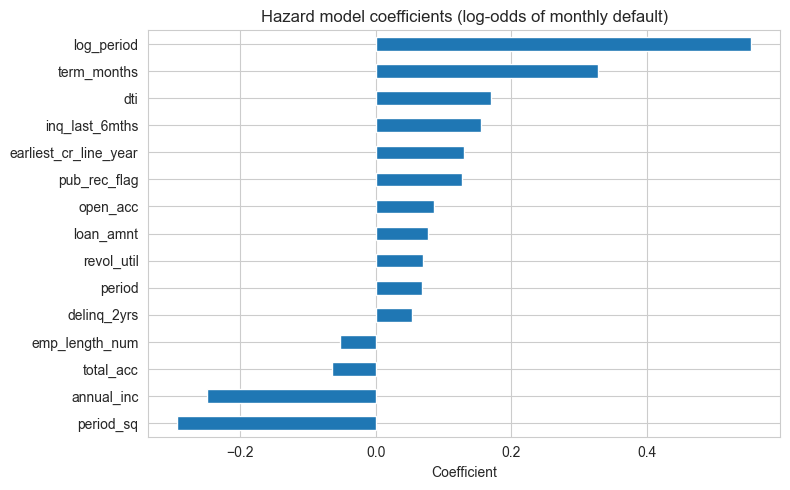

In [3]:
model = S.fit_hazard_model(pp)
coef = pd.Series(model.named_steps["clf"].coef_[0], index=model._feats).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
coef.plot(kind="barh", ax=ax)
ax.set_title("Hazard model coefficients (log-odds of monthly default)")
ax.set_xlabel("Coefficient"); plt.tight_layout(); plt.show()

## 2. Term Structure: 12-Month PD vs Lifetime PD

We score survival curves on the out-of-time test loans, then collapse each loan's curve into a 12-month PD and a lifetime PD.

Actual default rate (OOT sample): 0.258
Mean 12-month PD : 0.070
Mean lifetime PD : 0.294


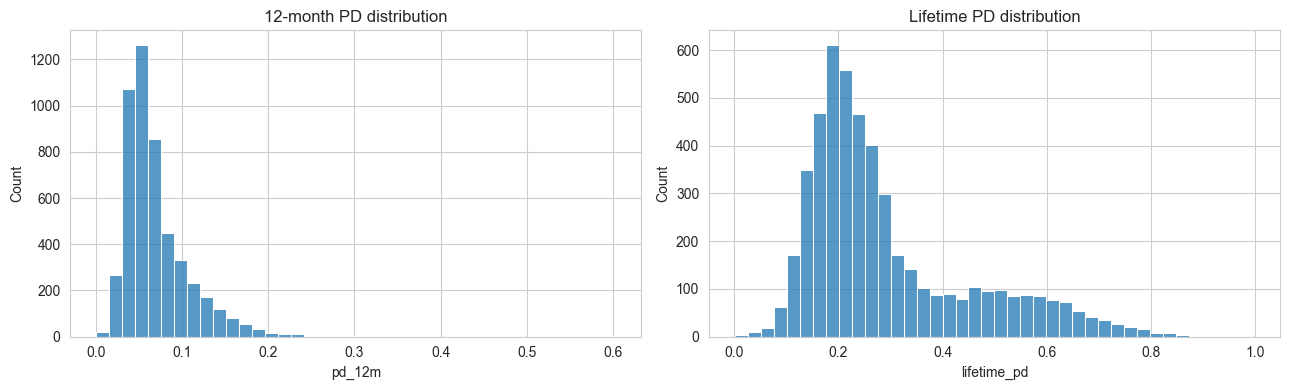

In [4]:
score = df.loc[test_idx].head(5000).reset_index(drop=True)
curves = S.survival_curves(model, score)
pd_sum = S.summarize_pd(curves)
print(f"Actual default rate (OOT sample): {score[C.TARGET].mean():.3f}")
print(f"Mean 12-month PD : {pd_sum['pd_12m'].mean():.3f}")
print(f"Mean lifetime PD : {pd_sum['lifetime_pd'].mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(pd_sum["pd_12m"], bins=40, ax=ax[0]); ax[0].set_title("12-month PD distribution")
sns.histplot(pd_sum["lifetime_pd"], bins=40, ax=ax[1]); ax[1].set_title("Lifetime PD distribution")
plt.tight_layout(); plt.show()

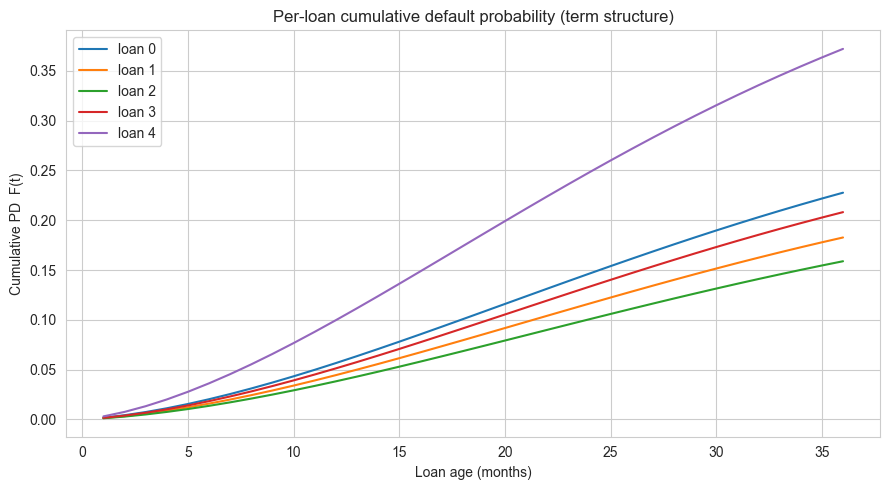

In [5]:
# Example survival curves for a few loans
fig, ax = plt.subplots(figsize=(9, 5))
for loan in [0, 1, 2, 3, 4]:
    c = curves[curves["_loan"] == loan]
    ax.plot(c["period"], c["cum_pd"], label=f"loan {loan}")
ax.set_xlabel("Loan age (months)"); ax.set_ylabel("Cumulative PD  F(t)")
ax.set_title("Per-loan cumulative default probability (term structure)")
ax.legend(); plt.tight_layout(); plt.show()

**Interpretation:** lifetime PD is always ≥ 12-month PD (more time, more chances to default). The mean lifetime PD lands close to the realized default rate, a basic sanity check that the survival model is calibrated. The gap between the two curves is the economic content IFRS 9 cares about: a loan with a low 12-month PD but a high lifetime PD is exactly the kind of exposure that should carry a lifetime loss allowance once its risk increases.

## 3. IFRS 9 Staging

IFRS 9 sorts every exposure into three stages that determine the size of the loss allowance:

| Stage | Condition | Allowance |
|---|---|---|
| **Stage 1** | Performing, no significant increase in credit risk | **12-month** ECL |
| **Stage 2** | Significant Increase in Credit Risk (SICR) since origination | **Lifetime** ECL |
| **Stage 3** | Credit-impaired (defaulted) | **Lifetime** ECL, PD = 1 |

A full SICR test re-measures each loan's lifetime PD over time and compares it to the PD expected at origination. With a single data snapshot we approximate SICR with a relative + absolute rule (lifetime PD both high in absolute terms and well above the portfolio median) and label it as a proxy.

Stage distribution:
  Stage 1: 3,658 loans (73.2%)
  Stage 2: 51 loans (1.0%)
  Stage 3: 1,291 loans (25.8%)


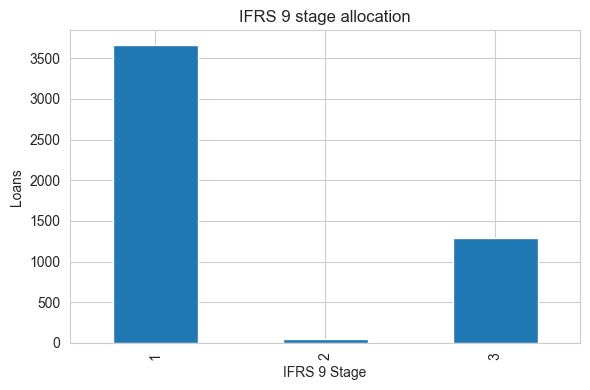

In [6]:
stage = S.assign_ifrs9_stage(pd_sum, score[C.TARGET])
counts = stage.value_counts().sort_index()
print("Stage distribution:")
for s, n in counts.items():
    print(f"  Stage {s}: {n:,} loans ({n/len(stage):.1%})")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax)
ax.set_xlabel("IFRS 9 Stage"); ax.set_ylabel("Loans")
ax.set_title("IFRS 9 stage allocation"); plt.tight_layout(); plt.show()

## 4. Expected Credit Loss (ECL)

ECL discounts each month's marginal expected loss back to today:

$$\text{ECL} = \sum_t \text{marginalPD}(t) \times \text{LGD} \times \text{EAD} \times \frac{1}{(1+r)^{t/12}}$$

Capping the sum at 12 months gives the 12-month ECL (Stage 1); summing over the full term gives lifetime ECL (Stage 2/3). We use the loan's own interest rate as the discount rate and the portfolio LGD.

In [7]:
lgd_const = P.portfolio_lgd(df.loc[train_idx])
ead = score["funded_amnt"]
rate = (score["int_rate"] / 100.0) if "int_rate" in score else 0.12

ecl_12m = S.expected_credit_loss(curves, ead, lgd_const, rate, horizon_months=12)
ecl_life = S.expected_credit_loss(curves, ead, lgd_const, rate, horizon_months=None)

print(f"Portfolio LGD assumption : {lgd_const:.3f}")
print(f"Total 12-month ECL       : ${ecl_12m.sum():,.0f}")
print(f"Total lifetime ECL       : ${ecl_life.sum():,.0f}")
print(f"12m as share of lifetime : {ecl_12m.sum()/ecl_life.sum():.1%}")

# Staged allowance: Stage 1 -> 12m ECL, Stage 2/3 -> lifetime ECL
allowance = np.where(stage.to_numpy() == 1, ecl_12m.to_numpy(), ecl_life.to_numpy())
print(f"\nTotal IFRS 9 staged allowance: ${allowance.sum():,.0f}")

summary = {
    "mean_pd_12m": float(pd_sum["pd_12m"].mean()),
    "mean_lifetime_pd": float(pd_sum["lifetime_pd"].mean()),
    "stage_counts": {int(k): int(v) for k, v in counts.items()},
    "total_ecl_12m": float(ecl_12m.sum()),
    "total_ecl_lifetime": float(ecl_life.sum()),
    "total_staged_allowance": float(allowance.sum()),
    "portfolio_lgd": float(lgd_const),
}
(C.REPORTS_DIR / "survival_summary.json").write_text(json.dumps(summary, indent=2))
print("\nSaved reports/survival_summary.json")

Portfolio LGD assumption : 0.582
Total 12-month ECL       : $2,844,171
Total lifetime ECL       : $10,160,162
12m as share of lifetime : 28.0%

Total IFRS 9 staged allowance: $5,385,778

Saved reports/survival_summary.json


**Why this matters:** the 12-month ECL is a fraction of the lifetime ECL. When a loan migrates from Stage 1 to Stage 2 (its credit risk increases significantly), the lender must immediately recognize the *full lifetime* loss allowance — a step change in provisions. This staging cliff is the single most important mechanic IFRS 9 introduced, and the survival term structure is what makes it computable. A model that only outputs a static PD cannot produce these two numbers.